Topic 134 | Hierarchical Clustering - Agglomerative vs Divisive Methods

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans

# create simple dataset
x, _ = make_blobs(
    n_samples=200,
    cluster_std=0.9,
    centers=4,
    random_state=42
)

In [2]:
#Agglomerative (bottom-up)
agg = AgglomerativeClustering(n_clusters=3, linkage="ward") #minimize the sum of squared differnce
agg_label = agg.fit_predict(x)

# top-down
#biscectingmean practical divsion mothed
div = BisectingKMeans(n_clusters=3, random_state=42)
div_label = div.fit_predict(x)
div_label




array([1, 2, 2, 2, 0, 0, 1, 2, 1, 0, 0, 1, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0,
       2, 2, 2, 2, 2, 0, 2, 1, 0, 0, 2, 2, 2, 1, 2, 1, 2, 2, 0, 2, 0, 0,
       2, 1, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 0, 0, 2, 1, 2, 1, 0, 2, 2, 0,
       1, 2, 2, 2, 2, 2, 2, 0, 1, 0, 1, 2, 0, 2, 2, 1, 0, 2, 2, 2, 2, 2,
       1, 2, 0, 2, 1, 1, 1, 2, 2, 1, 0, 2, 2, 2, 2, 0, 2, 1, 2, 0, 0, 2,
       1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 0, 0,
       2, 2, 2, 1, 0, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 2, 0, 0, 2, 2, 1, 2,
       0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 0, 1, 1, 0, 1, 2, 2, 0, 0, 1, 0,
       1, 2, 2, 0, 2, 0, 2, 2, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 2, 1, 2,
       0, 1], dtype=int32)

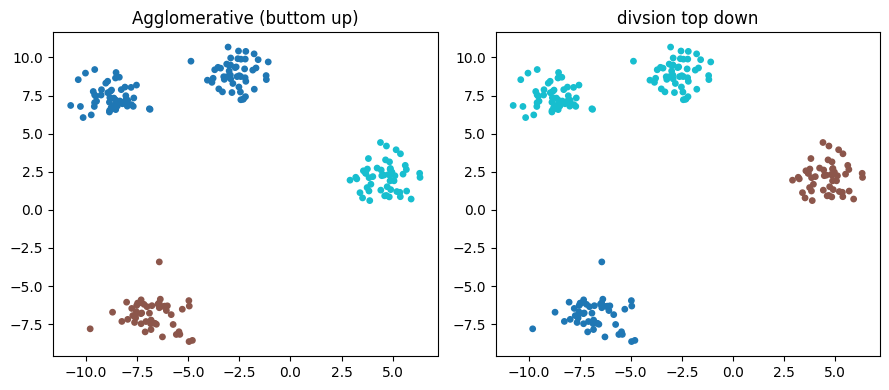

In [6]:
# visula compersion
fig, axes =plt.subplots(1,2, figsize=(9,4))
axes[0].scatter(x[:,0],x[:,1], c=agg_label,cmap='tab10',s=15)
axes[0].set_title("Agglomerative (buttom up)")

axes[1].scatter(x[:,0],x[:,1], c=div_label,cmap='tab10',s=15)
axes[1].set_title("divsion top down")

plt.tight_layout()
plt.show()

Topic 135 | Hierarchical Clustering - Dendrograms & Cluster Selection

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

x, _ = make_blobs(
    n_samples=50,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Compute hierarchical linkage
z = linkage(x, method="ward")

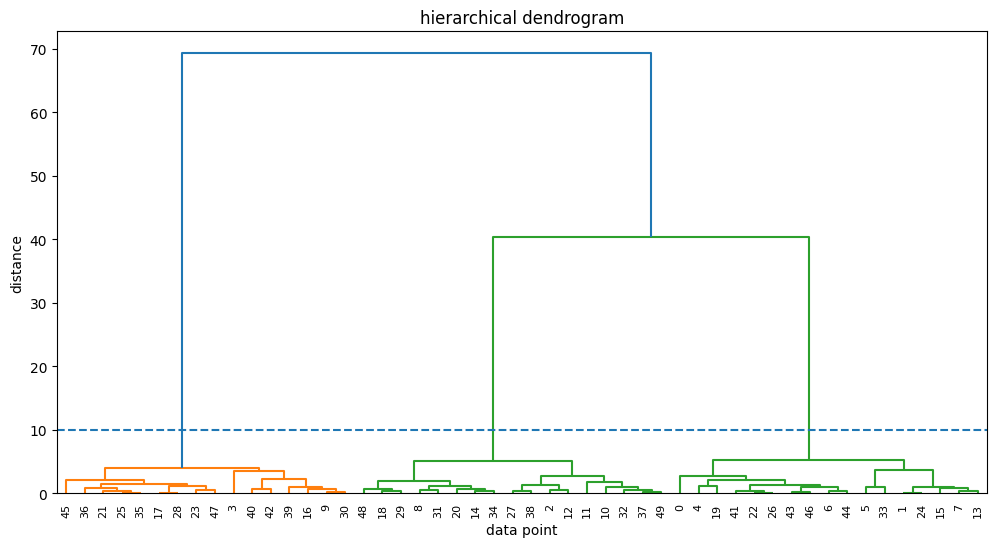

In [10]:
plt.figure(figsize=(12,6))
dendrogram(z)
plt.title("hierarchical dendrogram")
plt.xlabel("data point")
plt.ylabel("distance")
plt.axhline(y=10, linestyle="--")
plt.show()


In [11]:
k=3
cluster = fcluster(z,t=k, criterion="maxclust")
print("cluster assigment", cluster)

cluster assigment [3 3 2 1 3 3 3 3 2 1 2 2 2 3 2 3 1 1 2 3 2 1 3 1 3 1 3 2 1 2 1 2 2 3 2 1 1
 2 2 1 1 3 1 3 3 1 3 1 2 2]


Topic 136 | Hierarchical Clustering - Implementation with Scikit-Learn - Part I


In [13]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

data= load_iris()
x = pd.DataFrame(data.data, columns=data.feature_names)

print("datset", x.shape)
print(f"fist 5 row",x.head())


datset (150, 4)
fist 5 row    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [14]:
# hierchical agglomrative cluster
hc = AgglomerativeClustering(
    n_clusters=3,
     linkage="ward"
)

In [15]:
cluster_label = hc.fit_predict(x)
# attach clustor label to dataset
x["cluster"] = cluster_label
print("cluster count")
print(x['cluster'].value_counts())

cluster count
cluster
0    64
1    50
2    36
Name: count, dtype: int64


In [16]:
print("simple with cluster data")
print(x.head())

simple with cluster data
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  cluster
0                5.1               3.5  ...               0.2        1
1                4.9               3.0  ...               0.2        1
2                4.7               3.2  ...               0.2        1
3                4.6               3.1  ...               0.2        1
4                5.0               3.6  ...               0.2        1

[5 rows x 5 columns]


Topic 137 | Hierarchical Clustering - Implementation with Scikit-Learn - Part II

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

data = load_wine()
x = data.data

# standered feature
x_scaled = StandardScaler().fit_transform(x)
x_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

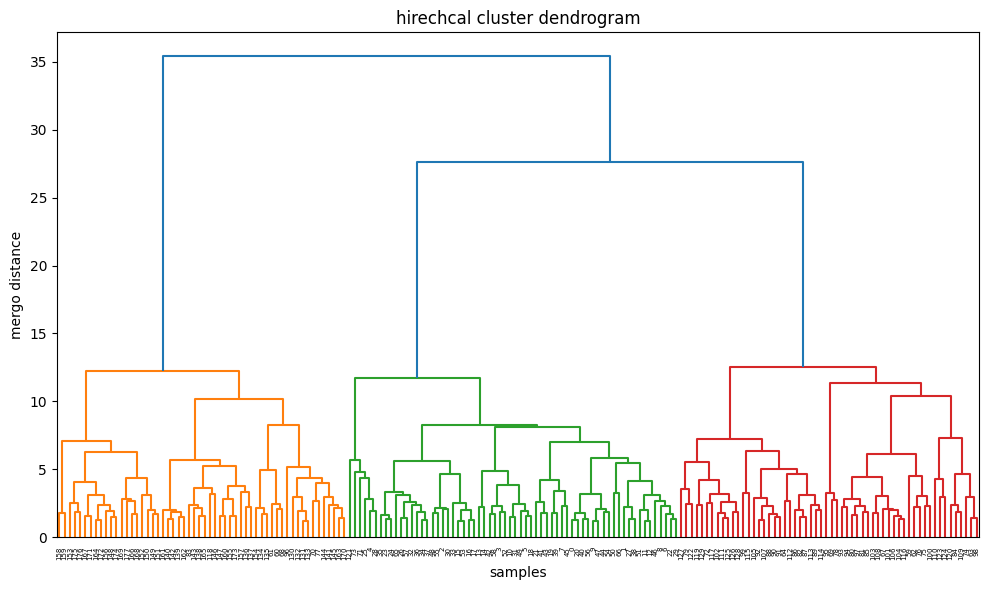

In [18]:
z = linkage(x_scaled, method="ward")

plt.figure(figsize=(10,6))
dendrogram(z)
plt.title("hirechcal cluster dendrogram")
plt.xlabel("samples")
plt.ylabel("mergo distance")
plt.tight_layout()
plt.show()


In [19]:
n_cluster =3

hc = AgglomerativeClustering(
    n_clusters=n_cluster,
    linkage="ward"
)

labels = hc.fit_predict(x_scaled)

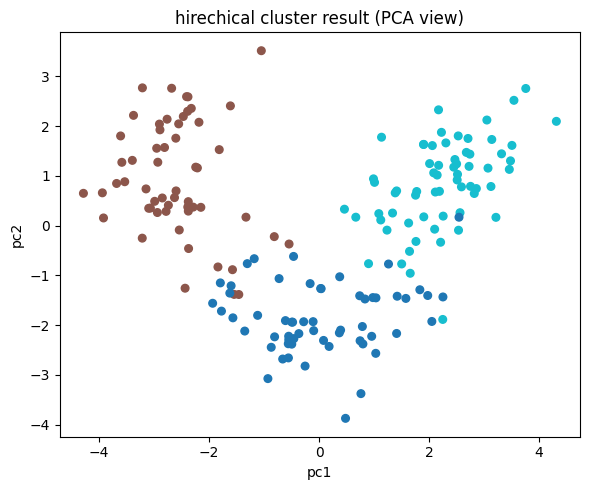

In [ ]:
# reduce 2d use pca visula
pca = PCA(n_components=2, random_state=42)
x_2d = pca.fit_transform(x_scaled)

plt.figure(figsize=(6,5))
plt.scatter(x_2d[:,0],x_2d[:,1], c=labels, cmap="tab10",s=30)
plt.title("hirechical cluster result (PCA view)")
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.tight_layout()
plt.show()

In [21]:
print("cluster_label", np.bincount(labels))

cluster_label [58 56 64]
